In [3]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, precision_recall_curve,
                             roc_auc_score, precision_score, recall_score, f1_score)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
RANDOM_STATE = 42
DATA_PATH = Path("../data/train.csv")
ARTIFACTS = Path("../artifacts")
ARTIFACTS.mkdir(exist_ok=True)

In [4]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(15000, 14)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15709511.0,Ch'ang,754.0,Spain,Male,40.0,8.0,102954.68,2.0,1.0,1.0,149238.35,0.0
1,1,15592761.0,Genovese,579.0,France,Female,28.0,1.0,0.00,2.0,1.0,0.0,64869.32,0.0
2,2,15579914.0,Yeh,744.0,France,Female,56.0,5.0,0.00,1.0,1.0,0.0,158816.03,1.0
3,3,15669611.0,Nwachinemelu,697.0,France,Male,29.0,2.0,0.00,2.0,1.0,0.0,55775.72,0.0
4,4,15761775.0,Hs?eh,628.0,France,Female,22.0,9.0,0.00,2.0,1.0,0.0,49653.39,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


In [5]:
df["Exited"] = df["Exited"].astype(int)
print(f"Ушедших клиентов: {df['Exited'].sum()} из {len(df)}: {df['Exited'].mean():.1%}")
df["Exited"].value_counts()

Ушедших клиентов: 3058 из 15000: 20.4%


Exited
0    11942
1     3058
Name: count, dtype: int64

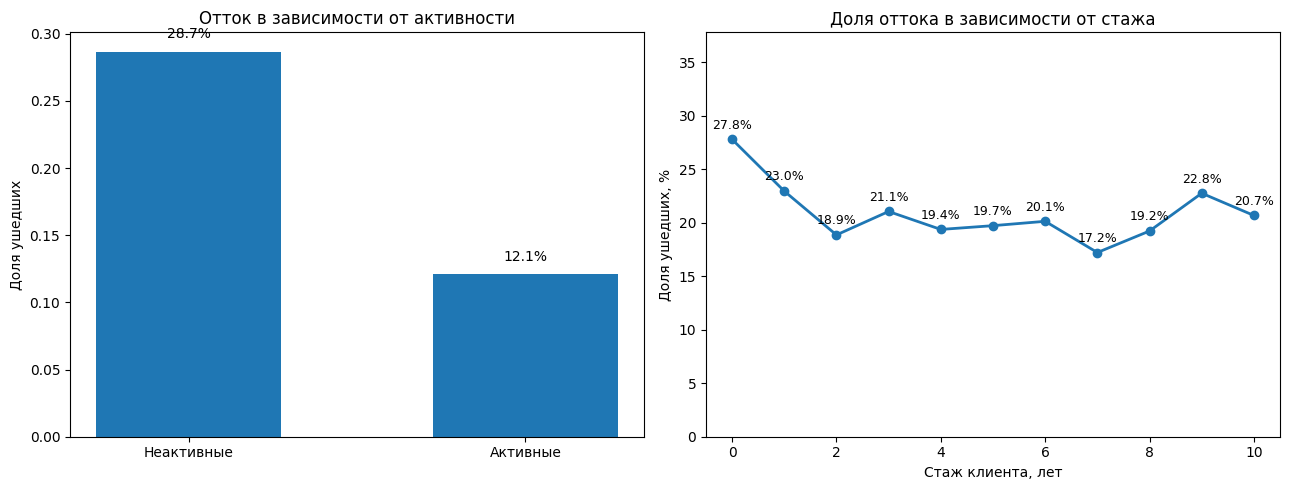

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

active_churn = (
    df.groupby("IsActiveMember")["Exited"]
      .mean()
)

axes[0].bar(
    ["Неактивные", "Активные"],
    active_churn.values,
    width=0.55
)

axes[0].set_ylabel("Доля ушедших")
axes[0].set_title("Отток в зависимости от активности")

for i, value in enumerate(active_churn.values):
    axes[0].text(
        i,
        value + 0.01,
        f"{value:.1%}",
        ha="center"
    )

churn_by_tenure = df.groupby("Tenure")["Exited"].mean() * 100

axes[1].plot(
    churn_by_tenure.index,
    churn_by_tenure.values,
    marker="o",
    linewidth=2
)

for x, y in zip(churn_by_tenure.index, churn_by_tenure.values):
    axes[1].text(
        x, y + 1,
        f"{y:.1f}%",
        ha="center",
        fontsize=9
    )

axes[1].set_title("Доля оттока в зависимости от стажа")
axes[1].set_xlabel("Стаж клиента, лет")
axes[1].set_ylabel("Доля ушедших, %")
axes[1].set_ylim(0, max(churn_by_tenure.values) + 10)
plt.tight_layout()
plt.show()

In [7]:
TARGET = "Exited"
DROP = ["id", "CustomerId", TARGET]
X = df.drop(columns=DROP)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(X_train.shape, X_test.shape)
print(f"доля оттока: train {y_train.mean():.3f}, test {y_test.mean():.3f}")

(12000, 11) (3000, 11)
доля оттока: train 0.204, test 0.204


In [7]:
X

,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,Ch'ang,754.0,Spain,Male,40.0,8.0,102954.68,2.0,1.0,1.0,149238.35
1,Genovese,579.0,France,Female,28.0,1.0,0.00,2.0,1.0,0.0,64869.32
2,Yeh,744.0,France,Female,56.0,5.0,0.00,1.0,1.0,0.0,158816.03
3,Nwachinemelu,697.0,France,Male,29.0,2.0,0.00,2.0,1.0,0.0,55775.72
4,Hs?eh,628.0,France,Female,22.0,9.0,0.00,2.0,1.0,0.0,49653.39
...,...,...,...,...,...,...,...,...,...,...,...
14995,Smith,667.0,France,Female,51.0,1.0,0.00,1.0,0.0,0.0,129870.93
14996,Iweobiegbunam,583.0,Spain,Male,54.0,6.0,0.00,2.0,0.0,1.0,172033.57
14997,Trevisano,684.0,France,Female,34.0,4.0,0.00,2.0,0.0,1.0,131363.57
14998,Onyekachi,439.0,Germany,Male,39.0,8.0,107764.75,2.0,1.0,1.0,131710.59


In [8]:
import json

rows = X_test.tail(500).to_dict(orient="records")

with open("good_batch.json", "w", encoding="utf-8") as f:
    json.dump({"rows": rows}, f, ensure_ascii=False, indent=2)

In [8]:
num_cols = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "HasCrCard", "IsActiveMember", "EstimatedSalary"]
cat_cols = [c for c in X.columns if c not in num_cols]
print("числовые:", num_cols)
print("категориальные:", cat_cols)

числовые: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
категориальные: ['Surname', 'Geography', 'Gender']


In [9]:
def make_report(name, y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    row = {
        "model": name,
        "ROC-AUC": roc_auc_score(y_true, proba),
        "PR-AUC": average_precision_score(y_true, proba),
        f"precision@{threshold}": precision_score(y_true, pred),
        f"recall@{threshold}": recall_score(y_true, pred),
        f"F1@{threshold}": f1_score(y_true, pred),
    }
    return row

In [10]:
preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), num_cols),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])

logreg = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000, C=1.0)),
])
logreg.fit(X_train, y_train)

proba_lr = logreg.predict_proba(X_test)[:, 1]
results = [make_report("logreg", y_test, proba_lr)]
pd.DataFrame(results).round(3)

,model,ROC-AUC,PR-AUC,precision@0.5,recall@0.5,F1@0.5
0,logreg,0.886,0.718,0.752,0.559,0.641


In [11]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
)

cat = CatBoostClassifier(
    iterations=1000, learning_rate=0.05, depth=6,
    eval_metric="AUC", random_seed=RANDOM_STATE, verbose=0,
)
cat.fit(X_tr, y_tr, cat_features=cat_cols,
        eval_set=(X_val, y_val), early_stopping_rounds=50)

print("последняя итерация:", cat.get_best_iteration())
proba = cat.predict_proba(X_test)[:, 1]
results.append(make_report("catboost", y_test, proba))
pd.DataFrame(results).round(3)

последняя итерация: 138


,model,ROC-AUC,PR-AUC,precision@0.5,recall@0.5,F1@0.5
0,logreg,0.886,0.718,0.752,0.559,0.641
1,catboost,0.934,0.818,0.800,0.662,0.725


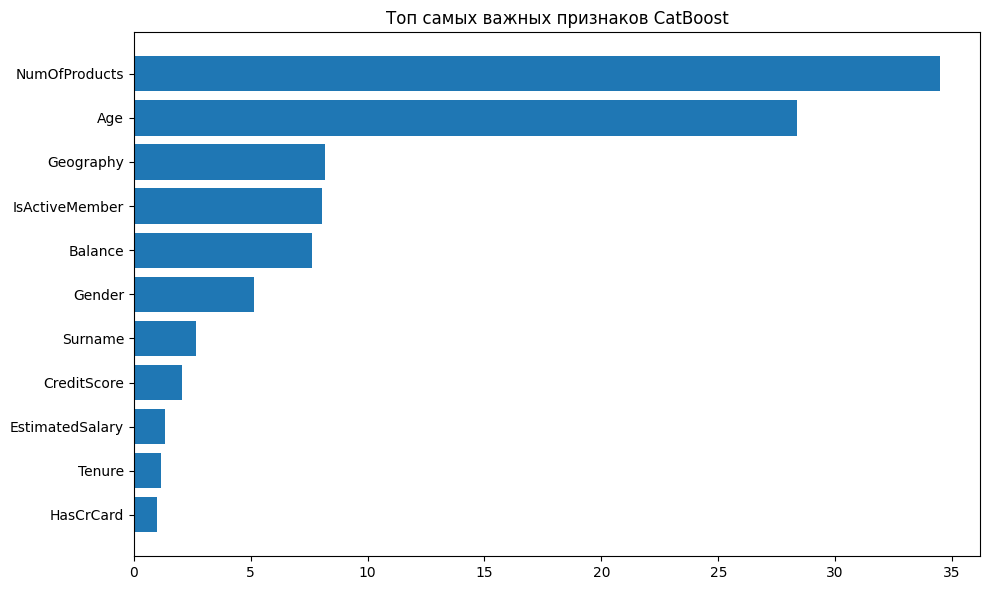

In [12]:
feature_importance = pd.Series(cat.get_feature_importance(), index=X_tr.columns).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(feature_importance.index, feature_importance.values)
plt.title("Топ самых важных признаков CatBoost")
plt.tight_layout()

порог 0.346: recall 0.750, precision 0.715


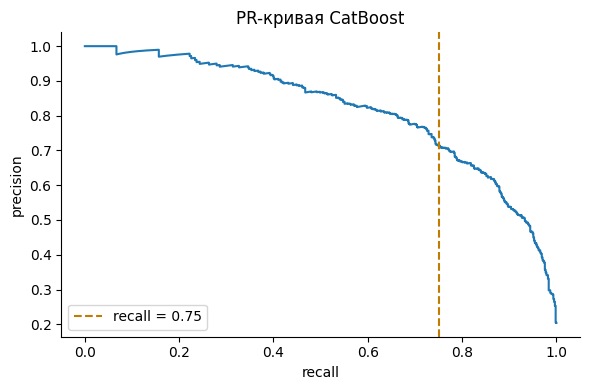

In [13]:
precision, recall, thresholds = precision_recall_curve(y_test, proba)
mask = recall[:-1] >= 0.75
best_threshold = thresholds[mask].max()
pred = (proba >= best_threshold).astype(int)

print(f"порог {best_threshold:.3f}: recall {recall_score(y_test, pred):.3f}, "
      f"precision {precision_score(y_test, pred):.3f}")

plt.figure(figsize=(6, 4))
plt.plot(recall, precision)
plt.axvline(0.75, color="#C07C00", linestyle="--", label="recall = 0.75")
plt.xlabel("recall")
plt.ylabel("precision")

plt.title("PR-кривая CatBoost")
plt.legend(); plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()

порог 0.282: recall 0.801, precision 0.668


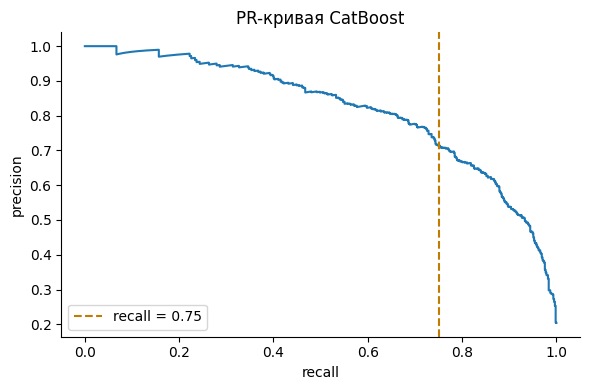

In [14]:
precision, recall, thresholds = precision_recall_curve(y_test, proba)
mask = recall[:-1] >= 0.8
best_threshold = thresholds[mask].max()
pred = (proba >= best_threshold).astype(int)

print(f"порог {best_threshold:.3f}: recall {recall_score(y_test, pred):.3f}, "
      f"precision {precision_score(y_test, pred):.3f}")

plt.figure(figsize=(6, 4))
plt.plot(recall, precision)
plt.axvline(0.75, color="#C07C00", linestyle="--", label="recall = 0.75")
plt.xlabel("recall")
plt.ylabel("precision")

plt.title("PR-кривая CatBoost")
plt.legend(); plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()

In [15]:
precision, recall, thresholds = precision_recall_curve(y_test, proba)
mask = recall[:-1] >= 0.75
best_threshold = thresholds[mask].max()
pred = (proba >= best_threshold).astype(int)

print(f"порог {best_threshold:.3f}: recall {recall_score(y_test, pred):.3f}, "
      f"precision {precision_score(y_test, pred):.3f}")

порог 0.346: recall 0.750, precision 0.715


In [16]:
import sklearn, catboost

metadata = {
    "model_name": "churn-catboost",
    "model_version": "1.0",
    "trained_at": pd.Timestamp.utcnow().isoformat(timespec="seconds"),
    "n_train": int(len(X_train)),
    "features": list(X.columns),
    "numeric_cols": num_cols,
    "categorical_cols": cat_cols,
    "threshold": float(round(best_threshold, 4)),
    "metrics_test": {k: round(float(v), 4) for k, v in results[1].items() if k != "model"},
    "libs": {"pandas": pd.__version__, "scikit-learn": sklearn.__version__, "catboost": catboost.__version__},
}

artifact = {
    "model": cat,
    "metadata": metadata
}

joblib.dump(
    artifact,
    ARTIFACTS / "churn_catboost.joblib"
)


sorted(p.name for p in ARTIFACTS.iterdir())

['churn_catboost.cbm',
 'churn_catboost.joblib',
 'churn_logreg.joblib',
 'metadata.json']

In [18]:
artifact = joblib.load(ARTIFACTS / "churn_catboost.joblib")

cat = artifact["model"]
meta = artifact["metadata"]
threshold = metadata["threshold"]

frame = pd.DataFrame([X_test.iloc[0].to_dict()])[meta["features"]]

score = float(cat.predict_proba(frame)[0, 1])

print(json.dumps({
    "score": round(score, 4),
    "churn": bool(score >= threshold),
    "true_churn": bool(y_test.iloc[0]),
    "model_version": meta["model_version"],
}, ensure_ascii=False))

{"score": 0.4526, "churn": true, "true_churn": true, "model_version": "1.0"}


In [19]:
batch_score = cat.predict_proba(X_test)[0, 1]
assert abs(batch_score - score) < 1e-9, "train-serve skew: одна строка и батч дают разные ответы"
print("одна строка и батч совпадают до 1e-9")

одна строка и батч совпадают до 1e-9
